# Phân tích khám phá dữ liệu kết quả học tập sinh viên

Bộ dữ liệu gồm **200,000 bản ghi sinh viên** và **15 thuộc tính**, phản ánh đồng thời nền tảng gia đình, hành vi học tập, điều kiện sinh hoạt, trạng thái tâm lý và kết quả học thuật. Trọng tâm phân tích không chỉ nằm ở việc mô tả dữ liệu, mà còn ở việc nhận diện các tín hiệu có khả năng hỗ trợ mô hình dự đoán `pass_fail`.

Bốn câu hỏi nghiên cứu định hướng toàn bộ phần EDA:

1. Chất lượng dữ liệu có đủ ổn định để làm nền cho mô hình Machine Learning hay không?
2. Hồ sơ sinh viên trong mẫu có đặc điểm trung tâm và mức phân hóa như thế nào?
3. Các nhóm biến hành vi, tâm lý và nền tảng gia đình liên hệ ra sao với kết quả học tập?
4. Những biến nào thể hiện tín hiệu rõ nhất với biến mục tiêu `pass_fail`?

In [1]:
import sys
!"{sys.executable}" -m pip install pandas matplotlib seaborn

## 1. Nguồn dữ liệu và phạm vi quan sát

Dữ liệu được lưu trữ trên Hadoop HDFS và truy xuất thông qua WebHDFS, phù hợp với bối cảnh dữ liệu có quy mô lớn và không đưa trực tiếp vào repository. Sau khi tải về môi trường phân tích, tập dữ liệu được xem như một lát cắt hồ sơ học tập của sinh viên.

Các biến quan sát bao phủ năm nhóm thông tin chính: nhân khẩu học (`gender`, `age`), nền tảng gia đình (`parental_education_level`, `family_income`), hành vi học tập (`daily_study_hours`, `attendance_rate`, `private_tutoring`), điều kiện sinh hoạt và tâm lý (`sleep_hours`, `stress_level`, `motivation_score`, `internet_quality`), cùng nhóm kết quả học thuật (`math_score`, `reading_score`, `writing_score`, `pass_fail`).

In [2]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen

# Thêm đường dẫn src để import file cấu hình settings.py
sys.path.append('../src')
from config.settings import HDFS_URL

# Trích xuất IP tĩnh của máy chủ từ HDFS_URL (Tailscale IP)
host_ip = HDFS_URL.split('://')[1].split(':')[0]
url = f"http://{host_ip}:9870/webhdfs/v1/student_data.csv?op=OPEN"

try:
    with urlopen(url) as response:
        df = pd.read_csv(response)
    print("Tải thành công dữ liệu từ HDFS (qua Tailscale)")
    print(f"Tổng số dòng dữ liệu: {len(df)}")
    
    # Hiển thị 5 dòng đầu để kiểm tra
    display(df.head())
except Exception as e:
    print(" Lỗi kết nối đến HDFS:", e)


Tải thành công dữ liệu từ HDFS (qua Tailscale)
Tổng số dòng dữ liệu: 200000


,gender,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,private_tutoring,internet_quality,math_score,reading_score,writing_score,pass_fail
0,Female,15,2,45000.0,2.9,0.916,8.3,6.0,16,False,2,21,29,29,Fail
1,Male,19,2,15000.0,2.8,0.760,6.8,5.0,58,False,3,56,37,45,Fail
2,Female,20,5,55000.0,4.0,0.894,8.2,6.0,51,False,3,60,51,63,Fail
3,Female,16,5,65000.0,4.6,0.888,6.2,6.0,49,False,3,58,54,34,Fail
4,Male,20,4,35000.0,4.3,0.923,7.3,4.0,62,False,2,80,57,73,Pass


## 1.2. Quy mô và cấu trúc dữ liệu

Quy mô, kiểu dữ liệu và tỷ lệ khuyết thiếu quyết định mức độ tin cậy của các phân tích tiếp theo. Với bài toán dự đoán `pass_fail`, phần cấu trúc dữ liệu còn cho biết biến nào là feature đầu vào, biến nào là nhãn mục tiêu, và biến nào có nguy cơ tạo rò rỉ thông tin nếu xử lý không đúng.

In [3]:
print("=== THÔNG TIN CHUNG VỀ BỘ DỮ LIỆU ===")
df.info()

=== THÔNG TIN CHUNG VỀ BỘ DỮ LIỆU ===
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   gender                    200000 non-null  str    
 1   age                       200000 non-null  int64  
 2   parental_education_level  200000 non-null  int64  
 3   family_income             195975 non-null  float64
 4   daily_study_hours         200000 non-null  float64
 5   attendance_rate           200000 non-null  float64
 6   sleep_hours               195887 non-null  float64
 7   stress_level              196087 non-null  float64
 8   motivation_score          200000 non-null  int64  
 9   private_tutoring          200000 non-null  bool   
 10  internet_quality          200000 non-null  int64  
 11  math_score                200000 non-null  int64  
 12  reading_score             200000 non-null  int64  
 13  writing_score    

In [4]:
print("\n=== KÍCH THƯỚC BỘ DỮ LIỆU ===")
print(f"Số lượng sinh viên (Dòng): {df.shape[0]}")
print(f"Số lượng thuộc tính (Cột): {df.shape[1]}")


=== KÍCH THƯỚC BỘ DỮ LIỆU ===
Số lượng sinh viên (Dòng): 200000
Số lượng thuộc tính (Cột): 15


### Nhận xét về cấu trúc dữ liệu

Bộ dữ liệu có **200,000 quan sát** và **15 biến**, tạo nền mẫu đủ lớn cho thống kê mô tả và các thử nghiệm mô hình hóa. Cấu trúc biến tương đối rõ: **12 biến số/định lượng**, **2 biến chuỗi** (`gender`, `pass_fail`) và **1 biến Boolean** (`private_tutoring`).

Giá trị khuyết chỉ tập trung ở ba biến: `family_income` (**4,025 dòng, khoảng 2.01%**), `sleep_hours` (**4,113 dòng, khoảng 2.06%**) và `stress_level` (**3,913 dòng, khoảng 1.96%**). Mức khuyết thiếu thấp, phân tán trong các biến có ý nghĩa phân tích, cho thấy việc bổ khuyết có kiểm soát hợp lý hơn so với loại bỏ dòng. Quy mô mẫu vì vậy vẫn được bảo toàn cho các phân tích sau.

# 2. Kiểm định chất lượng dữ liệu và tiền xử lý

Chất lượng dữ liệu được đánh giá qua ba khía cạnh: trùng lặp, ngoại lai và khuyết thiếu. Các xử lý ở phần này hướng đến hai mục tiêu phân tích: giữ lại tối đa thông tin thật của mẫu nghiên cứu và tránh tạo ra tín hiệu giả cho mô hình dự đoán.

## 2.1. Kiểm tra trùng lặp

Dòng trùng lặp có thể làm phóng đại một nhóm sinh viên và làm lệch các thống kê trung tâm. Kết quả kiểm tra cho biết mức độ độc lập của các quan sát trước khi đi vào mô tả phân phối và mô hình hóa.

In [5]:
Duplicate_value = df.duplicated().sum()
print(f"Phat hien {Duplicate_value} dong trung lap.")

Phat hien 0 dong trung lap.


Không phát hiện dòng trùng lặp trong bộ dữ liệu. Điều này củng cố độ tin cậy ban đầu của mẫu: toàn bộ **200,000 quan sát** có thể được giữ lại mà không làm tăng giả tạo tần suất của một nhóm sinh viên nào.

## 2.2. Miền giá trị và giá trị ngoại lai

Ngoại lai trong bộ dữ liệu giáo dục không mặc nhiên là lỗi. Một phần ngoại lai có thể phản ánh các sinh viên có thành tích rất thấp, mức chuyên cần bất thường, thu nhập gia đình rất cao hoặc hành vi học tập khác biệt. Vì vậy, phân tích ngoại lai tập trung vào việc phân biệt sai lệch logic với cực trị có ý nghĩa thực tế.

Các miền giá trị quan trọng gồm thang điểm 0-100, `attendance_rate` trong khoảng 0-1, và các biến thời lượng không âm trong phạm vi sinh hoạt hợp lý.

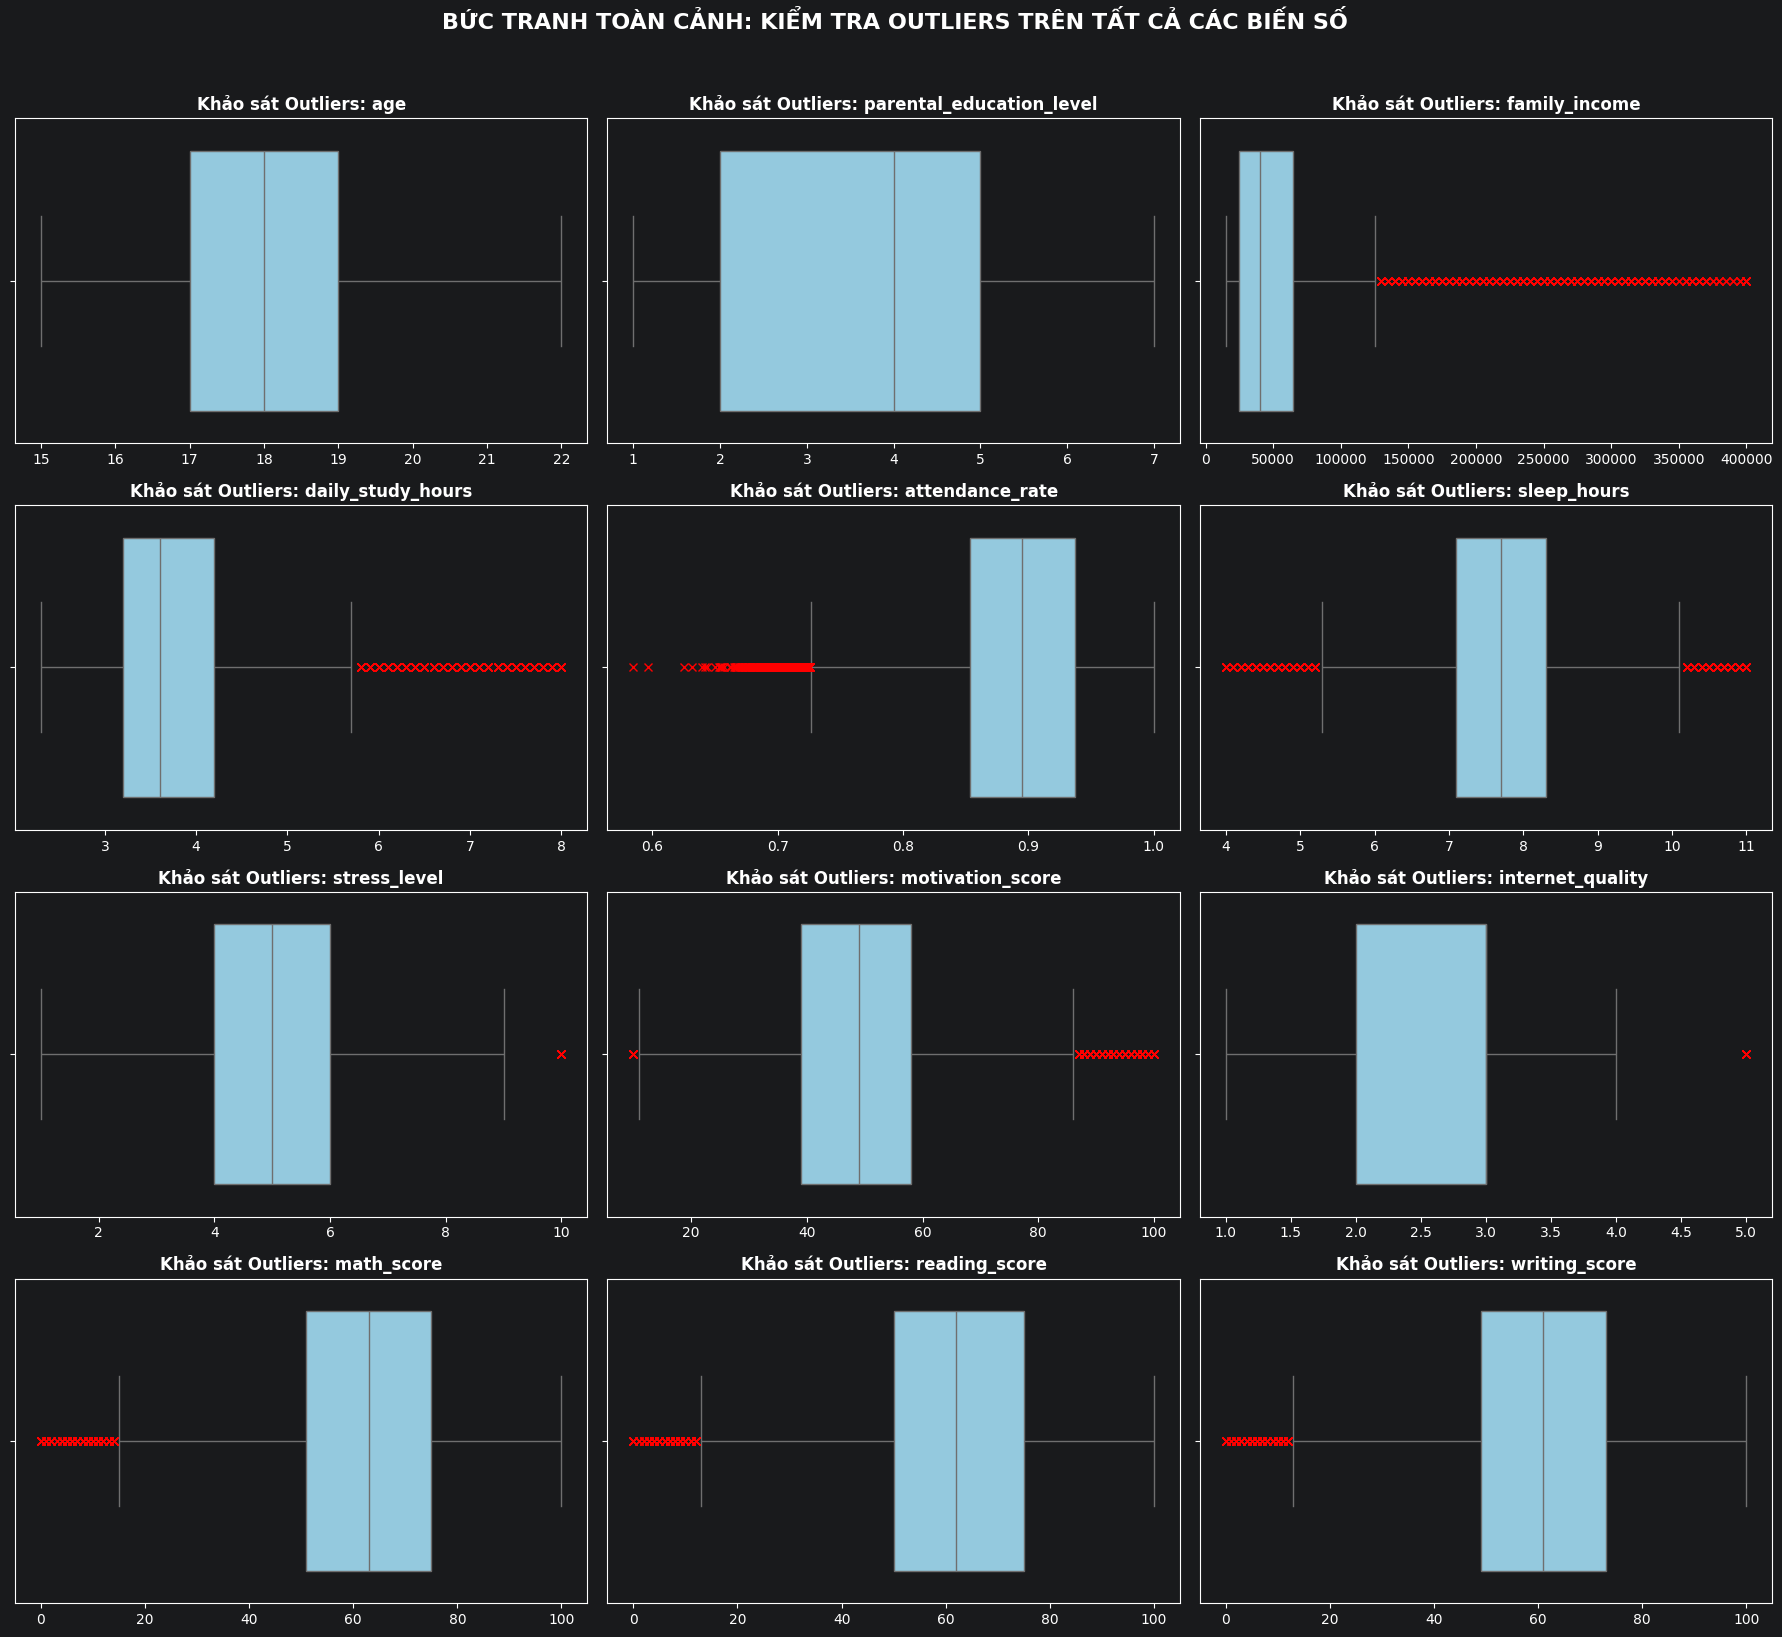

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tự động lấy danh sách tất cả các cột có kiểu dữ liệu là số
cac_cot_so = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = len(cac_cot_so)

# 2. Tính toán số lượng hàng cần vẽ (Mỗi hàng ta xếp 3 biểu đồ cho gọn và đẹp)
cols_per_row = 3
num_rows = (num_cols + cols_per_row - 1) // cols_per_row

# 3. Khởi tạo khung tranh tổng thể
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(18, 4 * num_rows))
fig.suptitle('BỨC TRANH TOÀN CẢNH: KIỂM TRA OUTLIERS TRÊN TẤT CẢ CÁC BIẾN SỐ', fontsize=16, fontweight='bold', y=1.02)

# Phẳng hóa mảng axes để dùng vòng lặp cho dễ
axes = axes.flatten()

# 4. Vòng lặp tự động vẽ Boxplot cho từng cột số
for i, col in enumerate(cac_cot_so):
    sns.boxplot(ax=axes[i], x=df[col], color='skyblue', flierprops={"marker": "x", "markeredgecolor": "red"})
    axes[i].set_title(f'Khảo sát Outliers: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

# 5. Ẩn đi các ô biểu đồ thừa nếu số lượng cột không chia hết cho 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.3. Diễn giải ngoại lai và quyết định xử lý

Boxplot và thống kê mô tả cho thấy các biến chính không vượt miền logic: điểm số nằm trong khoảng **0-100**, `attendance_rate` nằm trong khoảng **0.58-1.00**, `daily_study_hours` nằm trong khoảng **2.30-8.00** và `sleep_hours` nằm trong khoảng **4.00-11.00**. Các điểm nằm ngoài khoảng phân bố chính vì vậy được xem là cực trị hợp lệ, không phải lỗi nhập liệu.

- Nhóm điểm số (`math_score`, `reading_score`, `writing_score`) xuất hiện các mức rất thấp, bao gồm 0 điểm. Đây là nhóm quan sát có ý nghĩa lớn với bài toán `Fail`, vì chúng đại diện cho vùng rủi ro học tập cao.
- `family_income` lệch phải rõ rệt: trung bình khoảng **51,328** nhưng trung vị chỉ **40,000**, trong khi giá trị lớn nhất đạt **400,000**. Khoảng cách này cho thấy một nhóm nhỏ thu nhập rất cao đang kéo trung bình lên, nên trung vị phản ánh mức thu nhập điển hình tốt hơn.
- Các biến hành vi như `daily_study_hours`, `attendance_rate`, `sleep_hours`, `stress_level` và `motivation_score` có cực trị nhưng vẫn phù hợp với thực tế giáo dục, đặc biệt trong một mẫu lớn 200,000 quan sát.

Từ các quan sát trên, ngoại lai được giữ lại trong EDA. Quyết định này bảo toàn các trường hợp có rủi ro hoặc khác biệt hành vi, vốn có thể chứa tín hiệu quan trọng cho mô hình dự đoán.

## 2.4. Dữ liệu khuyết thiếu

Khuyết thiếu tập trung ở `family_income`, `sleep_hours` và `stress_level`, mỗi biến xấp xỉ 2%. Trong bối cảnh dự đoán `pass_fail`, điểm đáng chú ý không chỉ là tỷ lệ khuyết thiếu thấp, mà còn là cách bổ khuyết phải không sử dụng thông tin từ biến mục tiêu.

In [7]:
print("\n=== KIỂM TRA DỮ LIỆU BỊ KHUYẾT THIẾU ===")
print(df.isnull().sum())


=== KIỂM TRA DỮ LIỆU BỊ KHUYẾT THIẾU ===
gender                         0
age                            0
parental_education_level       0
family_income               4025
daily_study_hours              0
attendance_rate                0
sleep_hours                 4113
stress_level                3913
motivation_score               0
private_tutoring               0
internet_quality               0
math_score                     0
reading_score                  0
writing_score                  0
pass_fail                      0
dtype: int64


### 2.5. Lựa chọn bổ khuyết theo bản chất biến

Ba quyết định bổ khuyết phản ánh đặc điểm phân phối và vai trò của từng biến trong bài toán ML:

- `family_income` được bổ khuyết bằng **trung vị theo nhóm `parental_education_level`**. Thu nhập lệch phải mạnh, nên trung vị giảm ảnh hưởng của nhóm thu nhập rất cao và giữ được khác biệt theo nền tảng giáo dục gia đình.
- `sleep_hours` được bổ khuyết bằng **trung vị theo nhóm `age`**. Tuổi là thông tin đầu vào có sẵn trước dự đoán và có liên hệ hợp lý với nhịp sinh hoạt.
- `stress_level` được bổ khuyết bằng **trung vị theo các khoảng `motivation_score`**. Cách này giữ được khác biệt tương đối giữa các nhóm động lực học tập mà không mượn thông tin từ `pass_fail`.

Điểm quan trọng về mặt mô hình hóa là `pass_fail` không tham gia vào quá trình tạo `df_clean`. Nhãn mục tiêu chỉ xuất hiện sau đó trong các phân tích so sánh nhóm hoặc đánh giá liên hệ với target.

In [ ]:
# Tạo bản sao dữ liệu gốc để bổ khuyết dữ liệu theo hướng an toàn cho Machine Learning
df_clean = df.copy()

print("=== BẮT ĐẦU QUY TRÌNH BỔ KHUYẾT DỮ LIỆU KHÔNG DÙNG BIẾN MỤC TIÊU ===")

# 1. family_income -> dùng MEDIAN theo parental_education_level
if 'family_income' in df_clean.columns and 'parental_education_level' in df_clean.columns:
    df_clean['family_income'] = df_clean['family_income'].fillna(
        df_clean.groupby('parental_education_level')['family_income'].transform('median')
    )
    df_clean['family_income'] = df_clean['family_income'].fillna(df_clean['family_income'].median())
    print("Family_income: bổ khuyết bằng MEDIAN theo nhóm học vấn phụ huynh.")

# 2. sleep_hours -> dùng MEDIAN theo age, không dùng biến mục tiêu
if 'sleep_hours' in df_clean.columns and 'age' in df_clean.columns:
    df_clean['sleep_hours'] = df_clean['sleep_hours'].fillna(
        df_clean.groupby('age')['sleep_hours'].transform('median')
    )
    df_clean['sleep_hours'] = df_clean['sleep_hours'].fillna(df_clean['sleep_hours'].median())
    print("Sleep_hours: bổ khuyết bằng MEDIAN theo nhóm tuổi.")

# 3. stress_level -> dùng MEDIAN theo nhóm motivation_score, không dùng biến mục tiêu
if 'stress_level' in df_clean.columns and 'motivation_score' in df_clean.columns:
    df_clean['_motivation_band'] = pd.cut(
        df_clean['motivation_score'],
        bins=[0, 25, 50, 75, 100],
        include_lowest=True
    )
    df_clean['stress_level'] = df_clean['stress_level'].fillna(
        df_clean.groupby('_motivation_band', observed=False)['stress_level'].transform('median')
    )
    df_clean['stress_level'] = df_clean['stress_level'].fillna(df_clean['stress_level'].median())
    df_clean = df_clean.drop(columns=['_motivation_band'])
    print("Stress_level: bổ khuyết bằng MEDIAN theo nhóm motivation_score.")

print("\n--- KIỂM TRA TỔNG THỂ KẾT QUẢ SAU NGHIỆM THU ---")
print(f"Tổng số mẫu được bảo toàn nguyên vẹn: {len(df_clean)} dòng.")
print("Số lượng ô khuyết thiếu (Null) còn lại ở mỗi cột:")
display(df_clean[['family_income', 'sleep_hours', 'stress_level']].isnull().sum())

Sau bổ khuyết, `family_income`, `sleep_hours` và `stress_level` không còn giá trị khuyết, trong khi quy mô mẫu vẫn giữ ở **200,000 dòng**. Việc không dùng `pass_fail` trong tiền xử lý giúp tập dữ liệu sạch phù hợp hơn với giai đoạn huấn luyện mô hình.

# 3. Thống kê mô tả và đặc điểm mẫu nghiên cứu

Thống kê mô tả phác họa chân dung tổng thể của mẫu sinh viên: độ tuổi, điều kiện gia đình, mức chuyên cần, thời lượng tự học, giấc ngủ, trạng thái tâm lý và điểm số. Các chỉ số này là nền để hiểu dữ liệu trước khi diễn giải quan hệ với `pass_fail`.

## 3.1. Cấu trúc đọc thống kê mô tả

Các biến định lượng được nhìn qua trung bình, trung vị, độ lệch chuẩn và khoảng tứ phân vị. Với các biến lệch như `family_income`, trung vị và khoảng tứ phân vị có giá trị diễn giải cao hơn trung bình.

Các biến phân loại được đọc qua nhóm xuất hiện nhiều nhất và tần suất của nhóm đó. Riêng `pass_fail`, tỷ lệ giữa hai lớp cho thấy mức cân bằng ban đầu của bài toán phân loại.

In [9]:
import pandas as pd
# Cấu hình hiển thị số thực dạng thập phân cho dễ đọc, né định dạng e+05 khó nhìn
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("==================================1. THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) =========")
thong_ke_so = df_clean.describe()
display(thong_ke_so)

print("\n=============================== 2. THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH TÍNH (CATEGORICAL) =========")
thong_ke_chu = df_clean.describe(include=['str', 'bool'])
display(thong_ke_chu)

==================================1. THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) =========


,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,internet_quality,math_score,reading_score,writing_score
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,18.15,3.69,51328.30,3.75,0.89,7.71,5.10,48.58,2.91,62.97,62.51,61.00
std,1.65,1.61,35824.34,0.83,0.06,0.92,1.44,13.64,0.72,17.07,18.04,17.14
min,15.00,1.00,15000.00,2.30,0.58,4.00,1.00,10.00,1.00,0.00,0.00,0.00
25%,17.00,2.00,25000.00,3.20,0.85,7.10,4.00,39.00,2.00,51.00,50.00,49.00
50%,18.00,4.00,40000.00,3.60,0.90,7.70,5.00,49.00,3.00,63.00,62.00,61.00
75%,19.00,5.00,65000.00,4.20,0.94,8.30,6.00,58.00,3.00,75.00,75.00,73.00
max,22.00,7.00,400000.00,8.00,1.00,11.00,10.00,100.00,5.00,100.00,100.00,100.00



=============================== 2. THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH TÍNH (CATEGORICAL) =========


,gender,private_tutoring,pass_fail
count,200000,200000,200000
unique,2,2,2
top,Female,False,Pass
freq,104075,145236,109389


## 3.2. Diễn giải thống kê mô tả tổng quan

Bảng thống kê mô tả cho thấy mẫu nghiên cứu tập trung ở nhóm tuổi học sinh/sinh viên phổ thông muộn, với `age` trung bình **18.15**, trung vị **18**, và khoảng giá trị từ **15 đến 22**. Độ lệch chuẩn **1.65** cho thấy độ tuổi tương đối tập trung, không phải một mẫu trải rộng qua nhiều giai đoạn học tập khác nhau.

Về nền tảng gia đình, `parental_education_level` có trung bình **3.69** và trung vị **4**, cho thấy mức học vấn phụ huynh tập trung quanh nhóm trung bình của thang đo. `family_income` có trung bình **51,328.30** nhưng trung vị **40,000**, trong khi giá trị lớn nhất là **400,000**. Chênh lệch này xác nhận phân phối thu nhập lệch phải, nên khi diễn giải biến thu nhập cần ưu tiên trung vị và khoảng tứ phân vị hơn là chỉ nhìn trung bình.

Về hành vi học tập, sinh viên học trung bình **3.75 giờ/ngày**, trung vị **3.60 giờ**, với 50% mẫu nằm trong khoảng **3.20-4.20 giờ**. `attendance_rate` trung bình **0.89** và trung vị **0.90**, cho thấy mức chuyên cần chung khá cao; 75% sinh viên có tỷ lệ chuyên cần từ **0.85** trở lên.

Về giấc ngủ và tâm lý, `sleep_hours` trung bình **7.71 giờ**, trung vị **7.70 giờ**, nằm gần mức cân bằng sinh hoạt. `stress_level` trung bình **5.10** trên thang 1-10, phản ánh mức căng thẳng trung bình. `motivation_score` trung bình **48.58**, trung vị **49**, nhưng trải rộng từ **10 đến 100**, cho thấy động lực học tập có mức phân hóa đáng kể giữa các sinh viên.

Về biến phân loại, `gender` có nhóm phổ biến nhất là **Female** với **104,075 quan sát** (khoảng **52.04%**). `private_tutoring` chủ yếu là **False** với **145,236 quan sát** (khoảng **72.62%**), cho thấy phần lớn sinh viên không tham gia học thêm riêng. Biến mục tiêu `pass_fail` có **109,389 Pass** (khoảng **54.69%**) và **90,611 Fail** (khoảng **45.31%**), tức hai lớp tương đối cân bằng và phù hợp cho các phân tích phân loại sau này.

## 3.3. Phân phối điểm số học thuật

Ba biến `math_score`, `reading_score` và `writing_score` phản ánh trực tiếp kết quả học thuật. Phân phối của nhóm biến này cho biết mức độ phân hóa thành tích, đồng thời đặt ra câu hỏi quan trọng cho ML: điểm số là feature hợp lệ hay là thông tin hậu nghiệm gần với cách tạo nhãn `pass_fail`.

--- BẢNG SỐ LIỆU THỐNG KÊ MÔ TẢ ĐIỂM SỐ 3 MÔN ---


,math_score,reading_score,writing_score
count,200000.00,200000.00,200000.00
mean,62.97,62.51,61.00
std,17.07,18.04,17.14
min,0.00,0.00,0.00
25%,51.00,50.00,49.00
50%,63.00,62.00,61.00
75%,75.00,75.00,73.00
max,100.00,100.00,100.00


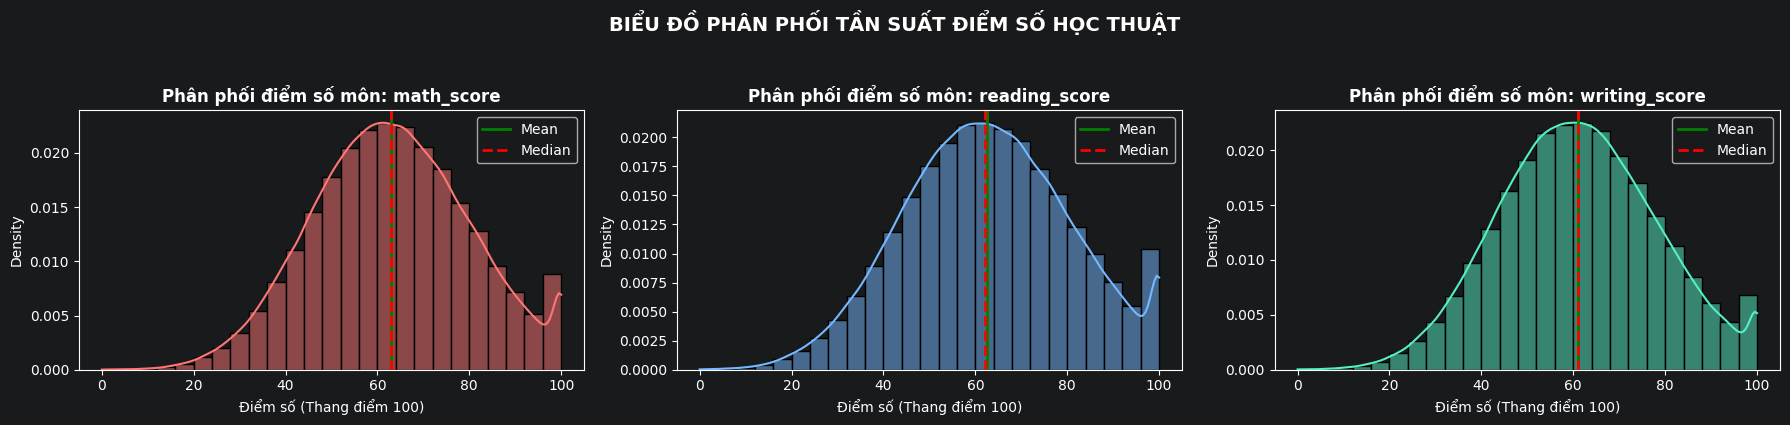

In [10]:
print("--- BẢNG SỐ LIỆU THỐNG KÊ MÔ TẢ ĐIỂM SỐ 3 MÔN ---")
display(df_clean[['math_score', 'reading_score', 'writing_score']].describe())

# Vẽ biểu đồ phân phối tần suất song song
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('BIỂU ĐỒ PHÂN PHỐI TẦN SUẤT ĐIỂM SỐ HỌC THUẬT', fontsize=14, fontweight='bold', y=1.05)

cac_mon = ['math_score', 'reading_score', 'writing_score']
mau_mon = ['#ff7675', '#74b9ff', '#55efc4']

for i, col in enumerate(cac_mon):
    sns.histplot(ax=axes[i], x=df_clean[col], kde=True, color=mau_mon[i], stat="density", bins=25)
    axes[i].axvline(df_clean[col].mean(), color='green', linestyle='-', linewidth=2, label=f'Mean')
    axes[i].axvline(df_clean[col].median(), color='red', linestyle='--', linewidth=2, label=f'Median')
    axes[i].set_title(f'Phân phối điểm số môn: {col}', fontweight='bold')
    axes[i].set_xlabel('Điểm số (Thang điểm 100)')
    axes[i].legend()

plt.tight_layout()
plt.show()

**Diễn giải:** Điểm trung bình ba môn nằm quanh mức 61-63 điểm: `math_score` **62.97**, `reading_score` **62.51** và `writing_score` **61.00**. Trung vị lần lượt là **63**, **62** và **61**, gần sát với trung bình, cho thấy phân phối điểm không bị lệch mạnh ở trung tâm.

Độ lệch chuẩn của ba môn nằm trong khoảng **17.07-18.04**, phản ánh mức phân hóa thành tích tương đối rõ. Khoảng tứ phân vị cho thấy 50% sinh viên nằm trong vùng điểm khoảng **49-75**, trong khi vẫn tồn tại cả nhóm điểm rất thấp và nhóm đạt điểm tuyệt đối. Điều này làm cho các biến điểm số vừa có giá trị mô tả năng lực học tập, vừa có thể đóng vai trò mạnh trong phân tích liên hệ với `pass_fail`.

# 4. Phân tích hai biến theo bối cảnh giáo dục

## 4.1. Trình độ học vấn phụ huynh và thu nhập gia đình

Mối liên hệ giữa `parental_education_level` và `family_income` phản ánh tầng nền kinh tế - giáo dục của sinh viên. Đây là nhóm thông tin có thể ảnh hưởng gián tiếp đến điều kiện học tập, khả năng tiếp cận tài nguyên và môi trường hỗ trợ ngoài lớp học.

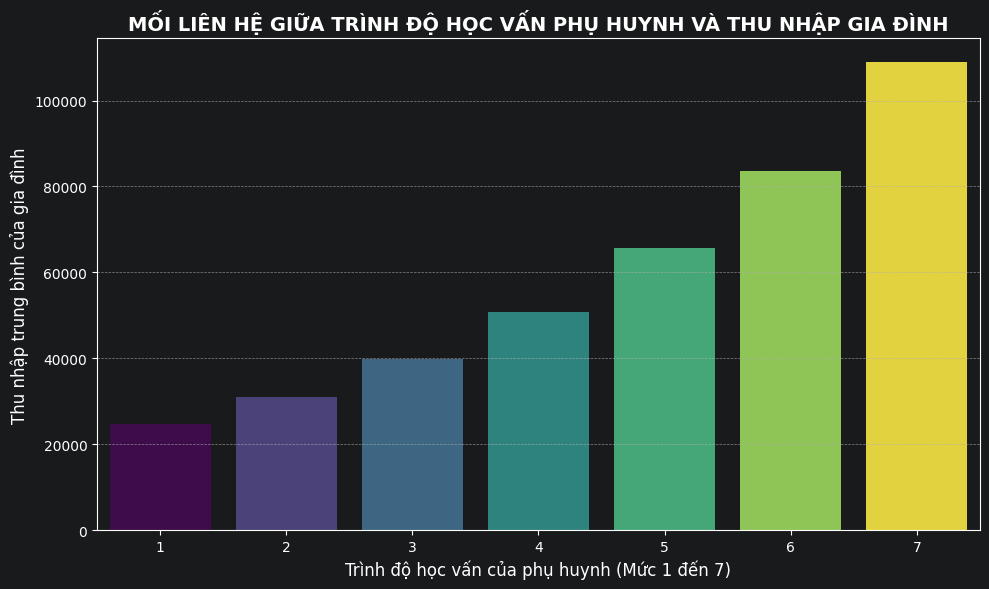

In [11]:
# Thiết lập kích thước biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ cột
sns.barplot(
    x='parental_education_level',
    y='family_income',
    data=df_clean,
    palette='viridis',
    hue='parental_education_level', # Gắn hue bằng đúng trục x để hết bị cảnh báo
    legend=False,                   # Tắt cái bảng chú thích (vì không cần thiết)
    errorbar=None
)

# Thêm tiêu đề và nhãn
plt.title('MỐI LIÊN HỆ GIỮA TRÌNH ĐỘ HỌC VẤN PHỤ HUYNH VÀ THU NHẬP GIA ĐÌNH', fontsize=14, fontweight='bold')
plt.xlabel('Trình độ học vấn của phụ huynh (Mức 1 đến 7)', fontsize=12)
plt.ylabel('Thu nhập trung bình của gia đình', fontsize=12)

# Thêm lưới đứt nét ngang cho dễ nhìn mốc tiền
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Diễn giải:** Thu nhập gia đình trung bình tăng theo mức học vấn của phụ huynh. Mẫu dữ liệu vì vậy thể hiện một gradient kinh tế - giáo dục khá rõ: nền tảng học vấn cao hơn thường đi kèm điều kiện tài chính tốt hơn. Đây là quan hệ thống kê trong mẫu quan sát, không đủ để kết luận học vấn phụ huynh là nguyên nhân duy nhất tạo ra khác biệt thu nhập.

## 4.2. Hành vi, tâm lý học tập và kết quả Đậu/Rớt

Ba biến `motivation_score`, `sleep_hours` và `daily_study_hours` được so sánh theo `pass_fail` để quan sát khác biệt hành vi giữa hai nhóm kết quả. Đây là nhóm feature có ý nghĩa đặc biệt với bài toán cảnh báo sớm vì chúng có thể được ghi nhận trước khi điểm cuối kỳ xuất hiện.

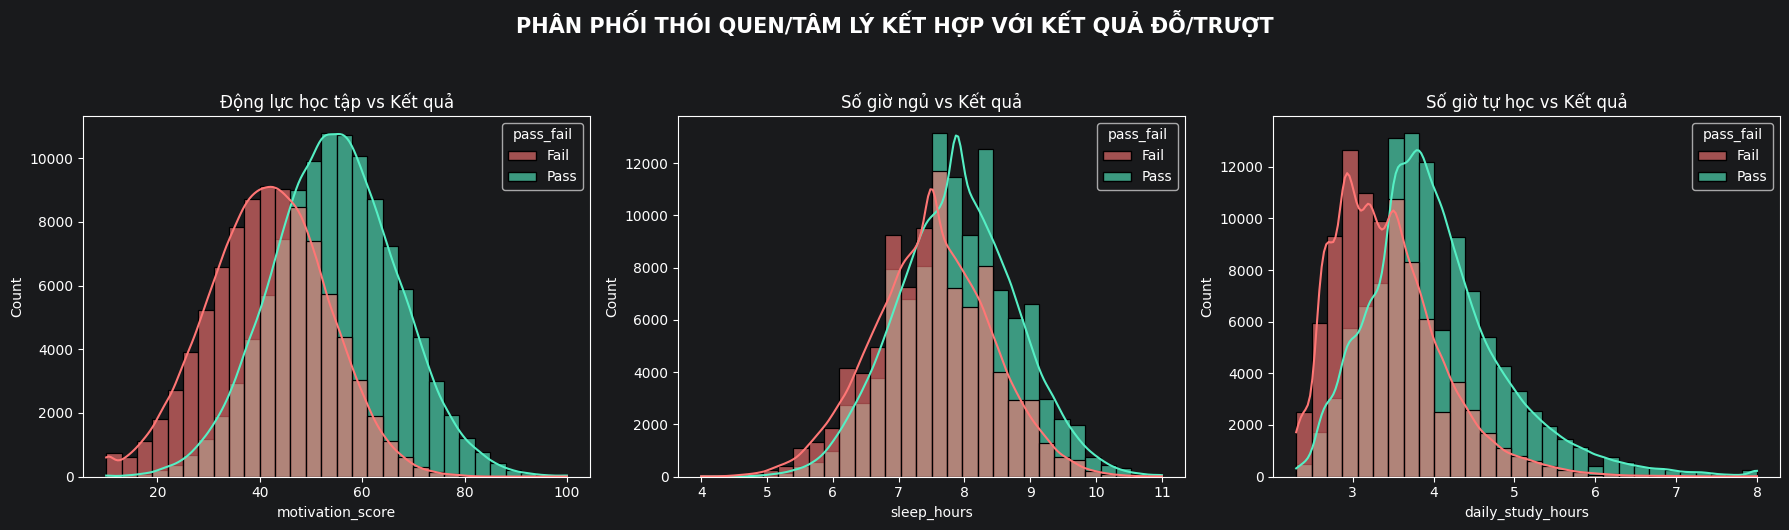

In [12]:
# Tạo khung gồm 3 biểu đồ con (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle('PHÂN PHỐI THÓI QUEN/TÂM LÝ KẾT HỢP VỚI KẾT QUẢ ĐỖ/TRƯỢT', fontsize=15, fontweight='bold', y=1.05)
# Định nghĩa bảng màu rõ ràng cho Pass (Xanh) và Fail (Đỏ)
palette_dict = {'Pass': '#55efc4', 'Fail': '#ff7675'}
# 1. Động lực học tập (motivation_score) phân rã theo pass_fail
sns.histplot(x='motivation_score', hue='pass_fail', data=df_clean, kde=True, ax=axes[0], palette=palette_dict, bins=30, alpha=0.6)
axes[0].set_title('Động lực học tập vs Kết quả', fontsize=12)
# 2. Số giờ ngủ (sleep_hours) phân rã theo pass_fail
sns.histplot(x='sleep_hours', hue='pass_fail', data=df_clean, kde=True, ax=axes[1], palette=palette_dict, bins=30, alpha=0.6)
axes[1].set_title('Số giờ ngủ vs Kết quả', fontsize=12)
# 3. Số giờ học mỗi ngày (daily_study_hours) phân rã theo pass_fail
sns.histplot(x='daily_study_hours', hue='pass_fail', data=df_clean, kde=True, ax=axes[2], palette=palette_dict, bins=30, alpha=0.6)
axes[2].set_title('Số giờ tự học vs Kết quả', fontsize=12)
# Tự động căn chỉnh khoảng cách giữa các biểu đồ
plt.tight_layout()
plt.show()

**Diễn giải:** Khác biệt giữa hai nhóm Pass/Fail thể hiện rõ hơn ở `motivation_score` và `daily_study_hours` so với `sleep_hours`. Điều này gợi ý rằng động lực và thời lượng tự học mang tín hiệu phân tách tốt hơn cho kết quả học tập, trong khi giấc ngủ đóng vai trò nền sinh hoạt ổn định hơn là một biến quyết định độc lập. Với mô hình dự đoán sớm, nhóm biến hành vi này đáng được ưu tiên hơn nhóm điểm số hậu nghiệm.

# 5. Phân tích tương quan định hướng biến mục tiêu

Trong bối cảnh xây dựng mô hình dự đoán `pass_fail`, tương quan được đọc theo quan hệ giữa từng feature và `target_encoded` (`Pass = 1`, `Fail = 0`). Cách nhìn này biến ma trận tương quan từ một mô tả tổng quát thành bước sàng lọc tín hiệu ban đầu cho mô hình.

Hệ số dương cho thấy giá trị biến cao hơn thường đi cùng nhóm `Pass`; hệ số âm cho thấy giá trị biến cao hơn thường đi cùng nhóm `Fail`. Độ lớn tuyệt đối của hệ số phản ánh sức mạnh tuyến tính ban đầu của tín hiệu. Dù vậy, correlation vẫn chỉ là quan hệ một biến - một target, chưa phản ánh tương tác giữa các biến hay hiệu quả dự đoán khi đưa vào mô hình.

Một điểm phương pháp quan trọng nằm ở nhóm điểm số. Nếu `pass_fail` được tạo trực tiếp từ kết quả thi, `math_score`, `reading_score` và `writing_score` sẽ là biến hậu nghiệm rất gần với định nghĩa nhãn. Với bài toán cảnh báo sớm, việc tách nhóm biến này khỏi feature set chính giúp mô hình phản ánh đúng mục tiêu dự báo trước kết quả; với bài toán phân loại sau khi đã có điểm, chúng có thể được giữ lại nhưng mô hình khi đó gần với quy tắc tổng hợp kết quả hơn là dự báo sớm.

========= ĐANG TÍNH TOÁN TƯƠNG QUAN THEO BIẾN MỤC TIÊU =========

=== TƯƠNG QUAN GIỮA CÁC BIẾN VÀ TARGET pass_fail (Pass=1, Fail=0) ===


,corr_with_pass_fail,abs_corr
reading_score,0.74,0.74
math_score,0.73,0.73
writing_score,0.73,0.73
motivation_score,0.48,0.48
parental_education_level,0.40,0.40
private_tutoring_encoded,0.38,0.38
daily_study_hours,0.36,0.36
family_income,0.26,0.26
attendance_rate,0.23,0.23
stress_level,-0.22,0.22



=== FEATURE CANDIDATES KHÔNG BAO GỒM ĐIỂM SỐ ===


,corr_with_pass_fail,abs_corr
motivation_score,0.48,0.48
parental_education_level,0.40,0.40
private_tutoring_encoded,0.38,0.38
daily_study_hours,0.36,0.36
family_income,0.26,0.26
attendance_rate,0.23,0.23
stress_level,-0.22,0.22
sleep_hours,0.21,0.21
internet_quality,0.19,0.19
age,-0.05,0.05


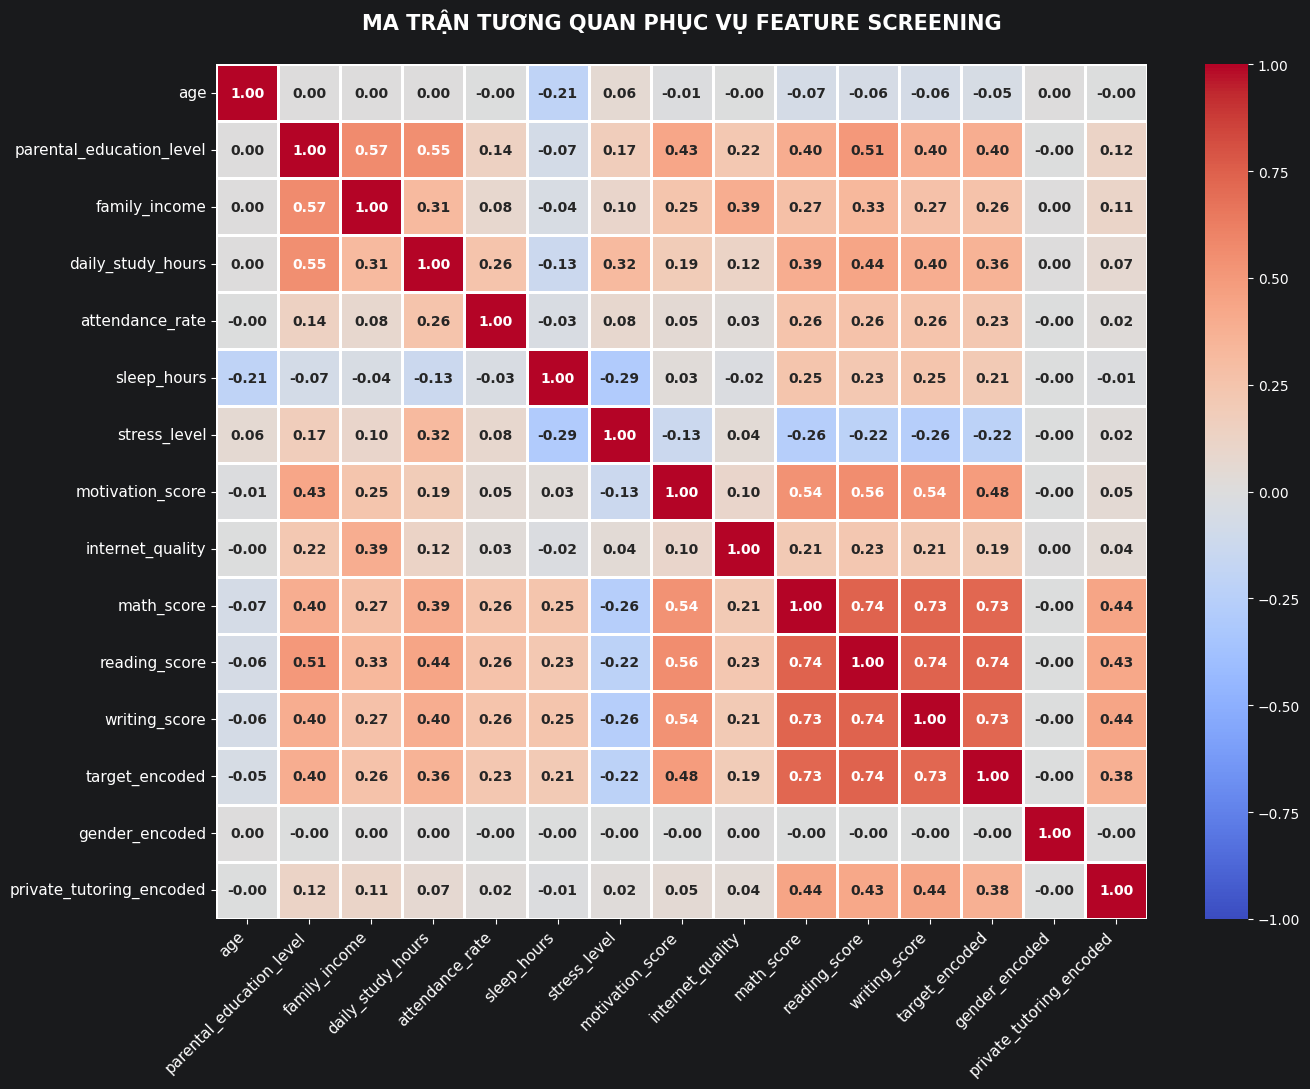

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("========= ĐANG TÍNH TOÁN TƯƠNG QUAN THEO BIẾN MỤC TIÊU =========")

# 1. Tạo bản sao tạm thời để mã hóa các biến định tính nhị phân thành dạng số
df_corr_all = df_clean.copy()

# Mã hóa target: Pass = 1, Fail = 0
if 'pass_fail' in df_corr_all.columns:
    df_corr_all['target_encoded'] = df_corr_all['pass_fail'].map({'Pass': 1, 'Fail': 0}).astype(float)

# Mã hóa gender: Male = 1, Female = 0
if 'gender' in df_corr_all.columns:
    df_corr_all['gender_encoded'] = df_corr_all['gender'].map({'Male': 1, 'Female': 0, 'M': 1, 'F': 0}).astype(float)

# Mã hóa private_tutoring: True = 1.0, False = 0.0
if 'private_tutoring' in df_corr_all.columns:
    df_corr_all['private_tutoring_encoded'] = df_corr_all['private_tutoring'].astype(float)

# 2. Lấy các biến numeric sau khi mã hóa
cac_cot_dinh_luong = df_corr_all.select_dtypes(include=['int64', 'float64']).columns

# 3. Tính ma trận tương quan Pearson
ma_tran_tong_luc = df_corr_all[cac_cot_dinh_luong].corr()

# 4. Bảng tương quan với target để phục vụ feature screening
if 'target_encoded' in ma_tran_tong_luc.columns:
    tuong_quan_target = (
        ma_tran_tong_luc['target_encoded']
        .drop(labels=['target_encoded'], errors='ignore')
        .dropna()
        .to_frame(name='corr_with_pass_fail')
    )
    tuong_quan_target['abs_corr'] = tuong_quan_target['corr_with_pass_fail'].abs()
    tuong_quan_target = tuong_quan_target.sort_values('abs_corr', ascending=False)

    print("\n=== TƯƠNG QUAN GIỮA CÁC BIẾN VÀ TARGET pass_fail (Pass=1, Fail=0) ===")
    display(tuong_quan_target)

    score_features = ['math_score', 'reading_score', 'writing_score']
    tuong_quan_target_khong_diem = tuong_quan_target.drop(index=score_features, errors='ignore')

    print("\n=== FEATURE CANDIDATES KHÔNG BAO GỒM ĐIỂM SỐ ===")
    display(tuong_quan_target_khong_diem)

# 5. Heatmap tổng thể để kiểm tra đa cộng tuyến giữa các biến
plt.figure(figsize=(14, 11))
sns.heatmap(
    ma_tran_tong_luc,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.8,
    annot_kws={"size": 10, "weight": "bold"},
    vmin=-1,
    vmax=1
)

plt.title('MA TRẬN TƯƠNG QUAN PHỤC VỤ FEATURE SCREENING', fontsize=15, fontweight='bold', pad=25)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

## 5.1. Diễn giải tương quan với biến mục tiêu

Kết quả tương quan với `target_encoded` cho thấy `pass_fail` chịu liên hệ mạnh nhất với nhóm biến điểm số. `reading_score` đạt hệ số **0.74**, `math_score` đạt **0.73** và `writing_score` đạt **0.73**. Đây là tín hiệu rất mạnh và hoàn toàn hợp lý: sinh viên có điểm các môn cao thường thuộc nhóm `Pass`. Tuy nhiên, chính mức tương quan cao này cũng cho thấy nhóm điểm số rất gần với bản chất của nhãn. Nếu mô hình được xây dựng để dự đoán Đậu/Rớt sau khi đã có điểm, ba biến này sẽ chi phối kết quả. Ngược lại, trong kịch bản cảnh báo sớm trước điểm cuối kỳ, nhóm điểm số mang tính hậu nghiệm và không còn phù hợp với feature set chính.

Khi loại ba biến điểm số, các tín hiệu còn lại tạo thành một bức tranh rõ hơn về những yếu tố có thể quan sát trước kết quả cuối kỳ. `motivation_score` là biến nổi bật nhất với tương quan **0.48**, cho thấy động lực học tập là tín hiệu hành vi mạnh nhất liên hệ với khả năng `Pass`. Tiếp theo là `parental_education_level` (**0.40**), `private_tutoring_encoded` (**0.38**) và `daily_study_hours` (**0.36**). Nhóm này gợi ý rằng khả năng vượt qua môn học không chỉ gắn với nỗ lực cá nhân, mà còn đi cùng nền tảng giáo dục gia đình và mức độ hỗ trợ học tập bên ngoài.

Các biến `family_income` (**0.26**), `attendance_rate` (**0.23**), `sleep_hours` (**0.21**) và `internet_quality` (**0.19**) có tương quan dương nhưng yếu hơn. Chúng vẫn mang thông tin bổ trợ cho mô hình, song khó đóng vai trò tín hiệu chính nếu đứng riêng lẻ. `stress_level` có tương quan âm **-0.22**, phản ánh chiều rủi ro: mức căng thẳng cao hơn thường đi cùng khả năng `Fail` cao hơn. Trong khi đó, `age` (**-0.05**) và `gender_encoded` gần **0.00** gần như không thể hiện quan hệ tuyến tính đáng kể với `pass_fail` trong mẫu dữ liệu này.

Từ góc nhìn mô hình hóa, không có một biến phi điểm số nào đủ mạnh để thay thế hoàn toàn nhóm điểm thi. Điều này hàm ý mô hình cảnh báo sớm cần kết hợp nhiều nhóm tín hiệu: động lực học tập, thời lượng tự học, học thêm, nền tảng gia đình, chuyên cần, giấc ngủ, stress và chất lượng Internet. Correlation ở đây đóng vai trò định hướng ban đầu cho feature selection; hiệu quả thực tế vẫn cần được kiểm chứng bằng mô hình đa biến và đánh giá trên tập kiểm tra.

Heatmap bổ sung thêm góc nhìn về sự chồng lấp thông tin giữa các feature. Nhóm điểm số có tương quan cao với nhau, nên khi cùng xuất hiện trong mô hình, hiện tượng đa cộng tuyến sẽ rõ hơn, đặc biệt với các mô hình tuyến tính như Logistic Regression. Với các mô hình cây, đa cộng tuyến ít gây bất ổn hệ số hơn nhưng vẫn có thể làm phân tán feature importance giữa các biến cùng mang một loại thông tin.

# 6. Tổng hợp phát hiện và hàm ý phân tích

Bộ dữ liệu có nền chất lượng tốt cho giai đoạn mô hình hóa: không ghi nhận dòng trùng lặp, tỷ lệ khuyết thiếu thấp, miền giá trị hợp lý và quy mô mẫu lớn. Sau bổ khuyết, toàn bộ **200,000 quan sát** vẫn được giữ lại.

Các phát hiện mô tả nổi bật gồm:

- Mẫu nghiên cứu tập trung quanh độ tuổi **18**, với mức chuyên cần trung bình cao (**0.89**) và thời lượng tự học trung bình khoảng **3.75 giờ/ngày**.
- Thu nhập gia đình lệch phải mạnh, thể hiện qua chênh lệch giữa trung bình **51,328.30** và trung vị **40,000**.
- Điểm số ba môn có trung bình quanh **61-63**, độ lệch chuẩn khoảng **17-18**, cho thấy thành tích học tập phân hóa rõ.
- Biến mục tiêu `pass_fail` tương đối cân bằng: **54.69% Pass** và **45.31% Fail**, thuận lợi cho bài toán phân loại.
- Correlation với `target_encoded` là trọng tâm để chọn feature sơ bộ; heatmap giữ vai trò nhận diện đa cộng tuyến.

Hàm ý chính cho Machine Learning là thời điểm dự đoán quyết định cấu trúc feature set. Nếu mô hình dự đoán sau khi đã có điểm, các biến điểm số sẽ chi phối mạnh kết quả. Nếu mô hình hướng đến cảnh báo sớm, việc loại `math_score`, `reading_score` và `writing_score` khỏi feature set chính sẽ phù hợp hơn; trọng tâm khi đó chuyển sang động lực học tập, thời lượng tự học, chuyên cần, stress, giấc ngủ, điều kiện gia đình và chất lượng Internet. Quy trình tiền xử lý cũng được nhìn như một pipeline fit trên tập huấn luyện và transform trên tập kiểm tra để tránh rò rỉ thông tin.